# STEMI — Pipeline huấn luyện & đánh giá v2 (khắc phục các điểm review từ v1)

**Dự án ACS-ECG-AI (Vinmec).** Notebook chạy độc lập, đầy đủ từ nạp dữ liệu thô đến bảng
kết quả cuối cùng trên tập TEST. Bài toán: phân loại nhị phân **STEMI** (ST-Elevation
Myocardial Infarction) từ tín hiệu ECG 12 chuyển đạo, 10 giây @ 500Hz, dùng cho triage cấp
cứu tim mạch — ưu tiên **Sensitivity/NPV** (rule-out) hơn Specificity/PPV vì chi phí bỏ sót
một ca nhồi máu cấp lớn hơn nhiều chi phí một cảnh báo giả.

**Dữ liệu:** bộ ACS-ECG 2026 (Du et al., 19.955 bản ghi đã xác nhận qua chụp mạch vành),
nạp trực tiếp từ file `.dat`/`.hea` (định dạng WFDB) và bảng nhãn CSV đi kèm.

---

## Các nhóm tối ưu giữ nguyên từ v1 (đã review, đạt chuẩn)

1. **Chia dữ liệu & chống rò rỉ theo bệnh nhân** — POOL/TEST rồi K-Fold trong POOL, không
   bệnh nhân nào xuất hiện ở hai tập, kiểm tra bằng assert tường minh.
2. **Chuẩn hoá z-score fit riêng theo train của từng fold** — không dùng thống kê toàn cục.
3. **Hàm loss chống mất cân bằng** — Focal Loss + label smoothing, α suy ra từ đúng tỷ lệ
   lớp của từng fold.
4. **Hiệu chuẩn Platt cross-fit trước khi ensemble** — giải quyết đúng vấn đề các kiến trúc
   có thang xác suất thô không tương thích.
5. **Ngưỡng vận hành đúng mục tiêu lâm sàng** — chốt tại Sensitivity ≥ 91% trên POOL (OOF),
   áp nguyên xi (không refit) lên TEST giữ riêng.
6. **Cache/checkpoint fingerprinting** — namespaced theo `PREPROCESS_VERSION`/`EXPERIMENT_TAG`,
   tránh dùng nhầm cache/checkpoint cũ khi đổi tham số.

## Các khắc phục mới trong v2 (theo review pipeline v1)

1. **[QUAN TRỌNG NHẤT] Highpass filter 0,5Hz → 0,05Hz.** Ở 0,5Hz, kể cả với filter
   zero-phase (`filtfilt`), phần năng lượng gần DC — đúng dải chứa thông tin mức chênh
   lệch đoạn ST tuyệt đối — vẫn bị suy hao. Tài liệu chuẩn hoá AHA/ACC/HRS khuyến nghị
   0,05Hz cho ECG chẩn đoán; 0,5Hz từng phổ biến trên máy theo dõi nhịp (rhythm monitor,
   không phải máy chẩn đoán) và được ghi nhận có thể tạo ST chênh giả. Vì đây là biến số
   cốt lõi của chính bài toán STEMI, rủi ro này được ưu tiên xử lý trước tiên.
2. **QC rà soát chuyển đạo flatline/rớt điện cực** (mục 6b, mới) — quét std từng chuyển đạo
   trên toàn bộ cache, báo cáo (không tự động loại) các bản ghi nghi ngờ để review thủ công.
3. **Augmentation bổ sung 2 loại nhiễu thực tế lâm sàng** — nhiễu điện lưới 50Hz (lưới điện
   Việt Nam) và mô phỏng một chuyển đạo rớt/tiếp xúc kém — bên cạnh 3 loại augmentation gốc
   (time-shift, nhiễu Gaussian, gain jitter) vẫn được giữ nguyên.
4. **Chẩn đoán trọng số Focal Loss** (mục 14b, mới) — dùng lại chính OOF đã có (không train
   lại) để kiểm tra xem γ=2 có đang hạ trọng số ca dương "dễ" quá mức so với những gì α đã
   tự điều chỉnh hay không, hỗ trợ quyết định có nên hạ γ hay không bằng số liệu cụ thể.
5. **Kiểm tra độ ổn định best_epoch trước khi train model FINAL** (mục 17, bổ sung) — cảnh
   báo nếu số epoch tối ưu dao động mạnh giữa các fold, vì model FINAL dùng trung vị của
   con số này mà không có validation riêng để early-stop.

**Không thay đổi:** kiến trúc 8 model, cấu trúc K-Fold, cách chọn ngưỡng, cách ensemble/hiệu
chuẩn, cách đánh giá TEST — toàn bộ phần đã được xác nhận đạt chuẩn ở v1.

**Kiểm soát rò rỉ:** chia theo **bệnh nhân** ở mọi bước (POOL/TEST, rồi K-Fold trong POOL) —
không bệnh nhân nào xuất hiện ở hai tập. TEST (15%) không được chạm tới cho đến bảng kết quả
cuối cùng.

## 1. Cài đặt thư viện

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

wfdb 4.3.1


## 2. Cấu hình

Mọi tham số của pipeline (đường dẫn, tiền xử lý, augmentation, loss, huấn luyện, ngưỡng vận
hành) tập trung ở một chỗ. `EXPERIMENT_TAG`/`PREPROCESS_VERSION` được gắn vào tên checkpoint
và cache: đổi các chuỗi này khi sửa logic tiền xử lý/huấn luyện để tránh vô tình dùng nhầm
cache/checkpoint của một cấu hình khác — hash chỉ theo danh sách bản ghi sẽ không phát hiện
được việc code tiền xử lý đã đổi.

In [ ]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"        # "debug" = 200 bản ghi / 3 epoch (kiểm tra pipeline nhanh) | "full" = toàn bộ

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"  # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

EXPERIMENT_TAG = "stemi_optimized_v2"     # đổi mỗi khi sửa loss/augmentation/kiến trúc
MODEL_DIR = PERSIST_DIR / "models" / f"stemi_{EXPERIMENT_TAG}"
OOF_DIR = PERSIST_DIR / "oof"

# ===================== THAM SỐ TÍN HIỆU =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
# BP_LOW = 0.05 (không phải 0.5) -- theo khuyến nghị AHA/ACC/HRS cho ECG chẩn đoán.
# Ở 0.5Hz, kể cả filter zero-phase (filtfilt, không lệch pha) vẫn suy hao năng lượng gần DC,
# đúng dải chứa mức chênh lệch ST tuyệt đối -- biến số cốt lõi của bài toán STEMI. 0.5Hz từng
# phổ biến trên máy theo dõi nhịp (không phải máy ECG chẩn đoán) và có thể tạo ST chênh giả.
BP_LOW, BP_HIGH, BP_ORDER = 0.05, 40.0, 3      # bandpass Butterworth (zero-phase qua filtfilt)
WINSORIZE_MV = 6.0                             # biên độ sau lọc vượt ±6mV -> nghi artifact, không phải QRS sinh lý
PREPROCESS_VERSION = "winsorize6mv_hp0.05_v2"  # đổi khi sửa nội dung preprocess()

# ===================== QC TÍN HIỆU (mới) =================
# Rà soát chuyển đạo flatline/rớt điện cực (mục 6b) chỉ BÁO CÁO, không tự loại. Nếu xác nhận
# là lỗi ghi thật, thêm record_stem vào danh sách dưới rồi chạy lại từ đầu notebook -- dùng lại
# đúng cơ chế loại bỏ đã kiểm chứng của KNOWN_BROKEN_RECORDS, không thêm luồng xử lý song song.
QC_EXTRA_EXCLUDE = []                    # điền record_stem sau khi review báo cáo QC mục 6b
FLATLINE_STD_THRESHOLD_MV = 0.02         # std một chuyển đạo dưới ngưỡng này (sau lọc) -> nghi ngờ

# ===================== THAM SỐ AUGMENTATION (chỉ áp cho tập train) ======
AUG_ENABLE = True
AUG_MAX_SHIFT = 20          # dịch thời gian tối đa (mẫu, ~40ms @ 500Hz) — mô phỏng jitter giữa các lần ghi
AUG_NOISE_STD = 0.02        # nhiễu Gaussian biên độ thấp, đo trên tín hiệu ĐÃ chuẩn hoá (std≈1)
AUG_GAIN_JITTER = 0.05      # hệ số gain ngẫu nhiên ±5%/chuyển đạo — mô phỏng lệch tiếp xúc điện cực
AUG_OP_PROB = 0.5           # xác suất áp mỗi phép augment riêng biệt cho mỗi mẫu (3 augment gốc)

# --- 2 augmentation mới: mô phỏng nhiễu thực tế lâm sàng, xác suất riêng (thấp hơn vì méo mạnh) ---
AUG_POWERLINE_PROB = 0.3    # xác suất chồng nhiễu điện lưới
AUG_POWERLINE_HZ = 50.0     # tần số lưới điện Việt Nam
AUG_POWERLINE_STD = 0.03    # biên độ nhiễu điện lưới, đo trên tín hiệu ĐÃ chuẩn hoá (std≈1)
AUG_LEAD_DROPOUT_PROB = 0.03  # xác suất một chuyển đạo bị thay bằng nhiễu thấp (mô phỏng rớt điện cực)

# ===================== THAM SỐ LOSS (Focal + label smoothing) ===========
FOCAL_GAMMA = 2.0            # 0 = tắt hoàn toàn phần điều chỉnh focal, quay về BCE có trọng số lớp
LABEL_SMOOTH_EPS = 0.02      # 0 = tắt label smoothing

# ===================== THAM SỐ HUẤN LUYỆN =========================
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15 trong POOL để early-stop
TEST_SIZE = 0.15                                # 15% bệnh nhân giữ riêng làm TEST, tách trước K-Fold
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
TARGET_LABEL = "STEMI"
CLASS_NAME = "STEMI"
K_FOLDS = 5
CANDIDATES = ["PlainCNN", "XResNet1D", "ConvNeXtV2_1D", "AiTiAMI",
              "ResNet1D", "SEResNet1D", "CNN+BiLSTM", "InceptionTime1D"]

# ===================== NGƯỠNG VẬN HÀNH LÂM SÀNG =========================
TARGET_SENSITIVITY = 0.91    # chính sách triage: rule-out tại Sensitivity >= 91%, chốt trên POOL (OOF)
ECE_BINS = 10

# Số ca trong paper gốc (toàn bộ 19.955 bản ghi); ta chỉ có nhãn cho ~90% nên dung sai ±10%
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197}
SANITY_TOL = 0.10

# Hai bản ghi lỗi đọc thật ở nguồn (wfdb báo ValueError ngay cả khi đọc đúng số mẫu thực có
# trong .dat) — không phải trường hợp thiếu vài mẫu vô hại có thể suy luận lại. Loại ngay ở
# bước tạo nhãn, trước khi chia tập/tính cache, để không rò rỉ ảnh hưởng vào bất kỳ tập con nào.
KNOWN_BROKEN_RECORDS = ["03228", "14262"]

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE
N_FOLDS_RUN = 1 if RUN_MODE == "debug" else K_FOLDS

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)
print("Ứng viên   :", ", ".join(CANDIDATES))
print("K-Fold     :", f"{K_FOLDS} fold, chạy {N_FOLDS_RUN} fold ở chế độ {RUN_MODE}")
print("Checkpoint :", MODEL_DIR)
print("Ngưỡng đích: Sensitivity >=", f"{TARGET_SENSITIVITY:.0%}", "(chốt trên POOL, áp lên TEST)")
print(f"Bandpass   : {BP_LOW}-{BP_HIGH} Hz, bậc {BP_ORDER}, zero-phase (filtfilt)")
print(f"QC flatline: ngưỡng std < {FLATLINE_STD_THRESHOLD_MV} mV | loại thêm: {QC_EXTRA_EXCLUDE or '(rỗng)'}")

Môi trường : Google Colab
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : STEMI
Ứng viên   : PlainCNN, XResNet1D, ConvNeXtV2_1D, AiTiAMI, ResNet1D, SEResNet1D, CNN+BiLSTM, InceptionTime1D
K-Fold     : 5 fold, chạy 5 fold ở chế độ full
Checkpoint : /content/drive/MyDrive/ACS-ECG-AI/outputs/models/stemi_stemi_optimized_v2
Ngưỡng đích: Sensitivity >= 91% (chốt trên POOL, áp lên TEST)
Bandpass   : 0.05-40.0 Hz, bậc 3, zero-phase (filtfilt)
QC flatline: ngưỡng std < 0.02 mV | loại thêm: (rỗng)


## 3. Chuẩn bị dữ liệu

In [ ]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        co_gi = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {co_gi}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        co_gi = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {co_gi}")

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

Giải nén ...
  27s
DATA_ROOT: /content/_extract/datasets | tồn tại: True


## 4. Seed & GPU

In [ ]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 x 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, kết quả không tái lập chính xác 100% giữa các máy.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA A100-SXM4-40GB


## 5. Dữ liệu và nhãn

Nạp bảng nhãn CSV, đối chiếu số ca dương với con số công bố trong paper gốc (sanity check),
rồi loại hai bản ghi lỗi đọc thật ở nguồn.

In [ ]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check so với paper ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'paper':>9}{'lệch':>9}")
ok_all = True
for name, expected in PAPER_COUNTS.items():
    got = int(df_raw[name].sum())
    delta = (got - expected) / expected
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{name:<8}{got:>11,}{expected:>9,}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print("\n!! CẢNH BÁO: số ca lệch quá ±10% so với paper — kiểm tra lại nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["STEMI"].astype(int)
print("Nhãn =", TARGET_LABEL, "(lấy trực tiếp từ cột cùng tên)")

# --- Loại bản ghi lỗi đọc thật ở nguồn + bản ghi QC thủ công (mục 6b, nếu có) ---
_exclude_list = list(dict.fromkeys(KNOWN_BROKEN_RECORDS + QC_EXTRA_EXCLUDE))  # gộp, giữ thứ tự, bỏ trùng
_broken_mask = df_all["record_stem"].isin(_exclude_list)
if _broken_mask.any():
    print(f"\nLoại {int(_broken_mask.sum())} bản ghi (lỗi đọc thật + QC thủ công mục 6b): "
          f"{df_all.loc[_broken_mask, 'record_stem'].tolist()}")
    display(df_all.loc[_broken_mask, ["record_stem", COL_PATIENT, TARGET_LABEL, "NSTEMI", "UA"]])
    df_all = df_all[~_broken_mask].reset_index(drop=True)
else:
    print("\nKhông thấy bản ghi lỗi đã biết trong dữ liệu hiện tại (nguồn có thể đã đổi) "
          "-- kiểm tra lại KNOWN_BROKEN_RECORDS/QC_EXTRA_EXCLUDE nếu nghi ngờ.")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    from sklearn.model_selection import train_test_split
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được    paper     lệch
STEMI         1,442    1,513   -4.7%   OK
NSTEMI        1,235    1,274   -3.1%   OK
UA            6,213    6,197    0.3%   OK
Nhãn = STEMI (lấy trực tiếp từ cột cùng tên)

Loại 2 bản ghi (lỗi đọc thật + QC thủ công mục 6b): ['14262', '03228']


,record_stem,Patient_id,STEMI,NSTEMI,UA
8428,14262,P08823,0,0,0
14724,03228,P15456,0,0,0



Nhãn STEMI: 1,442 dương (8.03%) / 16,516 âm
Dùng 17,958 bản ghi | 1,442 dương (8.03%)


## 6. Tiền xử lý tín hiệu & cache

Bandpass Butterworth (0,5–40 Hz) rồi **winsorize** biên độ ở ±6mV — ngưỡng này chặn artifact/
nhiễu điện cực (biên độ vượt xa QRS sinh lý bình thường ~1–3mV) mà không cắt cụt hình dạng
sóng bình thường, vì áp dụng bằng `np.clip` (giữ nguyên hình dạng phần trong ngưỡng, chỉ kẹp
phần đuôi cực đoan) chứ không co giãn lại toàn bộ tín hiệu. Winsorize thực hiện **sau** bandpass
và **trước** khi tính thống kê z-score, để vài giá trị cực đoan của từng bản ghi không kéo lệch
độ lệch chuẩn dùng chuẩn hoá bản ghi đó.

Cache tín hiệu đã tiền xử lý ra `.npy` (float16) để không phải lọc lại mỗi lần chạy; tên file
cache khoá theo hash của `PREPROCESS_VERSION` + danh sách bản ghi, nên sửa nội dung
`preprocess()` (đổi `PREPROCESS_VERSION`) sẽ tự động build cache mới thay vì âm thầm dùng cache
cũ đã lỗi thời.

In [ ]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo -> đọc đúng số mẫu thực có
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    filtered = filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1)
    winsorized = np.clip(filtered, -WINSORIZE_MV, WINSORIZE_MV)
    return np.ascontiguousarray(winsorized, dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5((PREPROCESS_VERSION + "|" + "|".join(records)).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn (đã đọc đúng số mẫu thực có, phần thiếu được zero-pad): {TRUNCATED}")

Cache đã đầy đủ: sig_full_n17958_4e74e044.npy
Cache: (17958, 12, 5000) float16


## 6b. QC: rà soát chuyển đạo flatline / rớt điện cực (mới)

Quét std của từng chuyển đạo trên toàn bộ cache đã tiền xử lý. Đây chỉ là **báo cáo**, không
tự động loại bỏ bản ghi nào — winsorize (mục 6) chỉ xử lý biên độ outlier lớn, không bắt được
trường hợp một chuyển đạo phẳng gần 0 do điện cực rớt (biên độ vẫn nằm trong khoảng cho phép).
Nếu sau khi review thấy đúng là lỗi ghi, thêm `record_stem` vào `QC_EXTRA_EXCLUDE` (mục 2) rồi
chạy lại từ đầu — dùng lại đúng cơ chế loại bỏ đã kiểm chứng của `KNOWN_BROKEN_RECORDS`.

In [ ]:
def scan_flatline(cache, chunk=256, threshold_mv=FLATLINE_STD_THRESHOLD_MV):
    """Std của từng chuyển đạo cho từng bản ghi, tính theo batch để không load hết cache vào RAM."""
    n = cache.shape[0]
    min_lead_std = np.empty(n, dtype=np.float32)
    flat_lead_idx = np.empty(n, dtype=np.int16)
    for i in range(0, n, chunk):
        b = np.asarray(cache[i:i + chunk], dtype=np.float32)   # (chunk, lead, time)
        lead_std = b.std(axis=2)                                # (chunk, lead)
        min_lead_std[i:i + chunk] = lead_std.min(axis=1)
        flat_lead_idx[i:i + chunk] = lead_std.argmin(axis=1)
    return min_lead_std, flat_lead_idx


LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"][:NUM_LEADS]

_min_std, _flat_lead = scan_flatline(CACHE)
_flag = _min_std < FLATLINE_STD_THRESHOLD_MV
print(f"QC flatline: ngưỡng std < {FLATLINE_STD_THRESHOLD_MV} mV -> "
      f"{int(_flag.sum())}/{len(df):,} bản ghi nghi ngờ")

if _flag.any():
    QC_FLATLINE_REPORT = pd.DataFrame({
        "record_stem": df.loc[_flag, "record_stem"].values,
        "patient": df.loc[_flag, COL_PATIENT].values,
        "lead_nghi_ngo": [LEAD_NAMES[i] for i in _flat_lead[_flag]],
        "std_thap_nhat_mV": _min_std[_flag],
        TARGET_LABEL: df.loc[_flag, TARGET_LABEL].values,
    }).sort_values("std_thap_nhat_mV").reset_index(drop=True)
    display(QC_FLATLINE_REPORT)
    print("\n-- Đây chỉ là RÀ SOÁT, chưa tự động loại. Nếu xác nhận là lỗi ghi thật,")
    print("   thêm record_stem vào QC_EXTRA_EXCLUDE ở mục 2 rồi chạy lại từ đầu notebook.")
else:
    QC_FLATLINE_REPORT = pd.DataFrame(
        columns=["record_stem", "patient", "lead_nghi_ngo", "std_thap_nhat_mV", TARGET_LABEL])
    print("Không phát hiện chuyển đạo flatline nào dưới ngưỡng.")

print(f"\nPhân phối std nhỏ nhất/bản ghi: min={_min_std.min():.4f}  "
      f"p1={np.percentile(_min_std, 1):.4f}  median={np.median(_min_std):.4f} mV")


QC flatline: ngưỡng std < 0.02 mV -> 162/17,958 bản ghi nghi ngờ


,record_stem,patient,lead_nghi_ngo,std_thap_nhat_mV,STEMI
0,15589,P00174,V6,0.000000,0
1,01984,P00315,V6,0.000000,0
2,02101,P00538,V1,0.000000,0
3,15429,P00474,V6,0.000000,0
4,10226,P01879,V5,0.000000,0
...,...,...,...,...,...
157,14106,P04100,aVF,0.019838,0
158,13091,P11113,aVF,0.019932,0
159,05213,P08831,aVF,0.019954,0
160,09654,P11451,aVL,0.019967,0



-- Đây chỉ là RÀ SOÁT, chưa tự động loại. Nếu xác nhận là lỗi ghi thật,
   thêm record_stem vào QC_EXTRA_EXCLUDE ở mục 2 rồi chạy lại từ đầu notebook.

Phân phối std nhỏ nhất/bản ghi: min=0.0000  p1=0.0205  median=0.0603 mV


## 7. Chia POOL / TEST theo bệnh nhân

Trích 15% **bệnh nhân** làm TEST giữ riêng trước khi làm bất cứ điều gì khác (K-Fold, chuẩn
hoá, chọn ngưỡng...). TEST không được chạm tới cho đến bảng kết quả cuối cùng.

In [ ]:
from sklearn.model_selection import train_test_split

y = df[TARGET_LABEL].values.astype(np.float32)

pat_all = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
pat_pool, pat_test = train_test_split(pat_all, test_size=TEST_SIZE,
                                      stratify=pat_all[TARGET_LABEL], random_state=SEED + 200)
TEST_PATIENTS = set(pat_test[COL_PATIENT])
IS_TEST = df[COL_PATIENT].isin(TEST_PATIENTS).to_numpy()
POOL_IDX = df.index[~IS_TEST].to_numpy()
TEST_IDX = df.index[IS_TEST].to_numpy()

assert not (set(df.loc[POOL_IDX, COL_PATIENT]) & TEST_PATIENTS), "RÒ RỈ: bệnh nhân TEST lọt vào POOL"
assert len(POOL_IDX) + len(TEST_IDX) == len(df), "POOL + TEST không phủ đúng toàn bộ df"

display(pd.DataFrame({
    "tập": ["POOL (train + K-Fold)", "TEST (giữ riêng)"],
    "bệnh nhân": [len(pat_pool), len(pat_test)],
    "bản ghi": [len(POOL_IDX), len(TEST_IDX)],
    "dương": [int(y[POOL_IDX].sum()), int(y[TEST_IDX].sum())],
    "tỷ lệ dương": [f"{y[POOL_IDX].mean():.2%}", f"{y[TEST_IDX].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    """z-score fit trên đúng tập con truyền vào (dùng riêng cho từng fold train)."""
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


mean_pool, std_pool = norm_stats(POOL_IDX)
print(f"\nz-score fit trên {len(POOL_IDX):,} bản ghi POOL (dùng cho model FINAL, mục 13)")

,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,POOL (train + K-Fold),14463,15281,1225,8.02%
1,TEST (giữ riêng),2553,2677,217,8.11%



z-score fit trên 15,281 bản ghi POOL (dùng cho model FINAL, mục 13)


## 8. Chia K-Fold theo bệnh nhân trong POOL

In [ ]:
from sklearn.model_selection import StratifiedKFold

pat_tbl = df.loc[POOL_IDX].groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
POS_RATE_ALL = float(y[POOL_IDX].mean())

FOLDS = {}          # k -> (train_idx, val_idx), chỉ trong POOL_IDX
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
for k, (_, va_pos) in enumerate(skf.split(pat_tbl, pat_tbl[TARGET_LABEL])):
    va_pats = set(pat_tbl.iloc[va_pos][COL_PATIENT])
    in_va_pool = df.loc[POOL_IDX, COL_PATIENT].isin(va_pats).to_numpy()
    FOLDS[k] = (POOL_IDX[~in_va_pool], POOL_IDX[in_va_pool])

# --- Kiểm tra không rò rỉ + phủ đúng POOL một lần ---
seen = set()
for k in range(K_FOLDS):
    pats_k = set(df.loc[FOLDS[k][1], COL_PATIENT])
    assert not (seen & pats_k), f"RÒ RỈ: bệnh nhân nằm ở hai fold (fold {k})"
    assert not (pats_k & TEST_PATIENTS), f"RÒ RỈ: bệnh nhân TEST lọt vào fold {k}"
    seen |= pats_k
    assert not (set(df.loc[FOLDS[k][0], COL_PATIENT]) & pats_k), \
        f"RÒ RỈ: bệnh nhân vừa ở train vừa ở val (fold {k})"
cover = np.concatenate([FOLDS[k][1] for k in range(K_FOLDS)])
assert len(cover) == len(POOL_IDX) and len(set(cover)) == len(POOL_IDX), \
    "Các fold không phủ đúng POOL_IDX một lần"
print(f"Giao nhau bệnh nhân giữa các fold: RỖNG -> OK | TEST không lọt vào fold nào -> OK")

rows, worst = [], 0.0
for k, (tr, va) in FOLDS.items():
    rate = float(y[va].mean())
    worst = max(worst, abs(rate - POS_RATE_ALL))
    rows.append({"fold": k, "bệnh nhân val": df.loc[va, COL_PATIENT].nunique(),
                 "bản ghi train": len(tr), "bản ghi val": len(va),
                 "dương val": int(y[va].sum()), "tỷ lệ dương val": rate,
                 "lệch (điểm %)": (rate - POS_RATE_ALL) * 100})
fold_df = pd.DataFrame(rows)
display(fold_df.style.format({"tỷ lệ dương val": "{:.2%}", "lệch (điểm %)": "{:+.2f}"}))
assert worst <= 0.02, f"Fold lệch tỷ lệ dương tới {worst:.2%} > 2 điểm %"
print(f"Tỷ lệ dương POOL {POS_RATE_ALL:.2%} | lệch lớn nhất giữa các fold {worst * 100:.2f} điểm % -> OK")

Giao nhau bệnh nhân giữa các fold: RỖNG -> OK | TEST không lọt vào fold nào -> OK


,fold,bệnh nhân val,bản ghi train,bản ghi val,dương val,tỷ lệ dương val,lệch (điểm %)
0,0,2893,12240,3041,245,8.06%,+0.04
1,1,2893,12236,3045,245,8.05%,+0.03
2,2,2893,12220,3061,246,8.04%,+0.02
3,3,2892,12219,3062,244,7.97%,-0.05
4,4,2892,12209,3072,245,7.98%,-0.04


Tỷ lệ dương POOL 8.02% | lệch lớn nhất giữa các fold 0.05 điểm % -> OK


## 9. Dataset & DataLoader

Augmentation (`augment=True`) chỉ áp cho **tập train của từng fold**, không bao giờ áp cho
tập validation/POOL-OOF/TEST — nếu không, chỉ số đánh giá sẽ đo trên tín hiệu đã bị nhiễu
nhân tạo thay vì tín hiệu thật. Ba phép biến đổi, mỗi phép có xác suất áp riêng
(`AUG_OP_PROB`), đều giữ nguyên hình dạng đoạn ST/QRS (không distort đặc trưng chẩn đoán):

- **Dịch thời gian** (≤ `AUG_MAX_SHIFT` mẫu, đệm bằng giá trị biên chứ không cuộn vòng để
  tránh tạo bước nhảy giả ở điểm nối) — mô phỏng lệch thời điểm bắt đầu ghi giữa các lần đo.
- **Nhiễu Gaussian biên độ thấp** trên tín hiệu đã chuẩn hoá — mô phỏng nhiễu điện tử.
- **Gain jitter riêng từng chuyển đạo** (±`AUG_GAIN_JITTER`) — mô phỏng tiếp xúc điện cực
  không hoàn toàn đồng nhất giữa các lần ghi.

In [ ]:
from torch.utils.data import DataLoader, Dataset


def _time_shift(x: np.ndarray, max_shift: int) -> np.ndarray:
    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift == 0:
        return x
    if shift > 0:
        return np.pad(x, ((0, 0), (shift, 0)), mode="edge")[:, :x.shape[1]]
    return np.pad(x, ((0, 0), (0, -shift)), mode="edge")[:, -x.shape[1]:]


def _powerline_noise(x: np.ndarray, fs: int, hz: float, std: float) -> np.ndarray:
    """Mô phỏng nhiễu điện lưới (50Hz tại VN) chồng lên MỌI chuyển đạo cùng lúc (giống nhiễu
    thật, vốn lan theo dây/đất chung) -- biên độ và pha ngẫu nhiên mỗi mẫu để tránh mô hình
    học vẹt một pha cố định thay vì học cách bỏ qua nhiễu."""
    t = np.arange(x.shape[1]) / fs
    phase = np.random.uniform(0, 2 * np.pi)
    amp = np.random.uniform(0.3, 1.0) * std
    noise = (amp * np.sin(2 * np.pi * hz * t + phase)).astype(np.float32)
    return x + noise[None, :]


def _lead_dropout(x: np.ndarray) -> np.ndarray:
    """Mô phỏng MỘT chuyển đạo bị rớt/tiếp xúc kém: thay bằng nhiễu biên độ thấp gần 0,
    không đụng tới các chuyển đạo còn lại. Xác suất áp thấp (AUG_LEAD_DROPOUT_PROB) vì đây
    là hỏng nặng, không nên xảy ra thường xuyên trong lúc train."""
    x = x.copy()
    lead = np.random.randint(0, x.shape[0])
    x[lead] = np.random.normal(0.0, 0.05, size=x.shape[1]).astype(np.float32)
    return x


class ECGDataset(Dataset):
    """z-score phải fit lại trên tập train CỦA TỪNG FOLD, không dùng chung một bộ thống kê
    toàn cục -- nếu không thì thống kê của fold này rò rỉ sang fold kia. `augment=True` chỉ
    được bật cho DataLoader huấn luyện của fold đó.
    """

    def __init__(self, indices, labels, mean, std, augment=False):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = np.asarray(mean).reshape(-1, 1)
        self.std = np.asarray(std).reshape(-1, 1)
        self.augment = augment and AUG_ENABLE

    def __len__(self):
        return len(self.indices)

    def _apply_augment(self, x: np.ndarray) -> np.ndarray:
        # --- 3 augmentation gốc (giữ nguyên từ v1) ---
        if np.random.rand() < AUG_OP_PROB:
            x = _time_shift(x, AUG_MAX_SHIFT)
        if np.random.rand() < AUG_OP_PROB:
            x = x + np.random.normal(0.0, AUG_NOISE_STD, size=x.shape).astype(np.float32)
        if np.random.rand() < AUG_OP_PROB:
            gain = np.random.uniform(1 - AUG_GAIN_JITTER, 1 + AUG_GAIN_JITTER,
                                     size=(NUM_LEADS, 1)).astype(np.float32)
            x = x * gain
        # --- 2 augmentation mới (v2): mô phỏng nhiễu thực tế lâm sàng ---
        if np.random.rand() < AUG_POWERLINE_PROB:
            x = _powerline_noise(x, FS, AUG_POWERLINE_HZ, AUG_POWERLINE_STD)
        if np.random.rand() < AUG_LEAD_DROPOUT_PROB:
            x = _lead_dropout(x)
        return x

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        x = (x - self.mean) / self.std
        if self.augment:
            x = self._apply_augment(x)
        return torch.from_numpy(np.ascontiguousarray(x)), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}


def make_loaders(tr_idx, va_idx, mean, std):
    ds_tr = ECGDataset(tr_idx, y[tr_idx], mean, std, augment=True)
    ds_va = ECGDataset(va_idx, y[va_idx], mean, std, augment=False)
    tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
    va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
    return tr, va


_tr_demo, _va_demo = make_loaders(*FOLDS[0], *norm_stats(FOLDS[0][0]))
xb, yb = next(iter(_va_demo))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(_tr_demo)} batch train, {len(_va_demo)} batch val (fold 0, minh hoạ)")
del _tr_demo, _va_demo

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 192 batch train, 48 batch val (fold 0, minh hoạ)


## 10. Hàm tính metric

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score, roc_curve)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def threshold_at_sensitivity(y_true, y_prob, target_sens):
    """Ngưỡng LỚN NHẤT sao cho Sensitivity thực tế vẫn >= target_sens -- dò trực tiếp trên điểm
    số của các ca dương (không nội suy tuyến tính trên ROC dạng bậc thang, vốn có thể cho kết
    quả tụt dưới mục tiêu)."""
    y_true = np.asarray(y_true).astype(int)
    pos_scores = np.sort(np.asarray(y_prob)[y_true == 1])[::-1]
    n_pos = len(pos_scores)
    k = min(int(np.ceil(target_sens * n_pos)), n_pos)
    return float(pos_scores[k - 1]) if k > 0 else 1.0


def style_df(df_, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df_.columns if c not in pct_cols and df_[c].dtype.kind in "iu"})
    try:
        return df_.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df_.columns])
    except Exception:
        return df_.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})
print("self-test threshold_at_sensitivity:",
      round(threshold_at_sensitivity(np.array([0, 0, 1, 1, 1]),
                                     np.array([.1, .3, .4, .6, .9]), 0.9), 3))

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}
self-test threshold_at_sensitivity: 0.4


## 11. Tám kiến trúc mạng nơ-ron 1D

Tám kiến trúc dưới đây nằm trong vùng hiệu năng gần nhau (chênh lệch AUROC trong khoảng
nhiễu của một lần chạy) ở bước sàng lọc kiến trúc ban đầu; hai kiến trúc yếu hơn rõ rệt
(TCN1D, Transformer1D trên tín hiệu 5000 mẫu) không đưa vào vòng huấn luyện đầy đủ này để
tiết kiệm chi phí GPU.

In [ ]:
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    """Mốc sàn: Conv-BN-ReLU-MaxPool xếp chồng, không có gì đặc biệt."""

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    """Skip connection giúp gradient đi xuyên qua mạng sâu."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    """Nhiều độ dài kernel song song -> bắt được cả sóng nhanh lẫn biến thiên chậm."""

    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    """CNN rút đặc trưng cục bộ, BiLSTM mô hình hoá quan hệ theo thời gian giữa các nhịp."""

    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)


# ---------------------------------------------------------------- 5. SEResNet1D
class SEBlock1D(nn.Module):
    """Squeeze-excitation: học trọng số quan trọng theo từng kênh (feature map)."""

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w


class SEResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.se = SEBlock1D(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.se(self.bn2(self.conv2(out)))
        return self.relu(out + idt)


class SEResNet1D(nn.Module):
    """ResNet1D + squeeze-excitation sau mỗi khối."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(SEResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 6. XResNet1D
class XResBlock1D(nn.Module):
    """Nhánh tắt kiểu xResNet: AvgPool + 1x1 conv thay vì strided conv khi downsample."""

    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.act = nn.SiLU(inplace=True)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.AvgPool1d(stride, ceil_mode=True), nn.Conv1d(c_in, c_out, 1, bias=False),
                nn.BatchNorm1d(c_out))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.act(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class XResNet1D(nn.Module):
    """Stem sâu (3 conv nhỏ xếp chồng) thay vì 1 conv to + SiLU -- biến thể tối ưu hoá của ResNet1D."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 5, 2, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(XResBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.SiLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 7. ConvNeXtV2_1D
class GRN1D(nn.Module):
    """Global Response Normalization (ConvNeXt V2) -- chuẩn hoá theo norm toàn cục của từng kênh."""

    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, channels))
        self.beta = nn.Parameter(torch.zeros(1, 1, channels))

    def forward(self, x):
        gx = torch.norm(x, p=2, dim=1, keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block1D(nn.Module):
    def __init__(self, channels, expand=4, dropout=0.1):
        super().__init__()
        self.dwconv = nn.Conv1d(channels, channels, 7, padding=3, groups=channels, bias=False)
        self.norm = nn.LayerNorm(channels)
        self.pw1 = nn.Linear(channels, channels * expand)
        self.act = nn.GELU()
        self.grn = GRN1D(channels * expand)
        self.pw2 = nn.Linear(channels * expand, channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        idt = x
        x = self.dwconv(x).transpose(1, 2)
        x = self.norm(x)
        x = self.pw2(self.grn(self.act(self.pw1(x))))
        x = self.drop(x).transpose(1, 2)
        return x + idt


class ConvNeXtV2Downsample1D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.norm = nn.BatchNorm1d(c_in)
        self.conv = nn.Conv1d(c_in, c_out, 2, stride=2, bias=False)

    def forward(self, x):
        return self.conv(self.norm(x))


class ConvNeXtV2_1D(nn.Module):
    """Khối depthwise-conv + LayerNorm + MLP mở rộng + GRN -- bản 1D của ConvNeXt V2."""

    def __init__(self, channels=(32, 64, 128, 256), depths=(1, 1, 2, 1), dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, channels[0], 4, stride=4, bias=False),
                                  nn.BatchNorm1d(channels[0]))
        stages, c_in = [], channels[0]
        for stage_i, (c_out, depth) in enumerate(zip(channels, depths)):
            if stage_i > 0:
                stages.append(ConvNeXtV2Downsample1D(c_in, c_out))
            stages += [ConvNeXtV2Block1D(c_out, dropout=dropout) for _ in range(depth)]
            c_in = c_out
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.LayerNorm(c_in), nn.Dropout(dropout), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.stages(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 8. AiTiAMI (tái hiện)
class AiTiAMIBlock1D(nn.Module):
    """Residual block chuẩn, kernel hẹp hơn ResNet1D (5 thay vì 7) để bắt chi tiết QRS/ST mịn hơn."""

    def __init__(self, c_in, c_out, k=5, stride=2, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class AiTiAMI(nn.Module):
    """Tái hiện theo MÔ TẢ KIẾN TRÚC trong Lee et al., Eur Heart J 2025 (ehaf004, ROMIAE):
    "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo.
    KHÔNG PHẢI model/trọng số gốc của Medical AI Co., Ltd -- bài báo không công bố kiến trúc chi
    tiết (sản phẩm thương mại). Sâu hơn (5 stage) và rộng hơn ResNet1D, head avg+max-pool nối tiếp.
    """

    def __init__(self, channels=(48, 96, 192, 256, 320), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 48, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(48), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 48
        for i, c_out in enumerate(channels):
            blocks.append(AiTiAMIBlock1D(c_in, c_out, stride=2 if i < 4 else 1))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in * 2, 128), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        feat = self.blocks(self.stem(x))
        pooled = torch.cat([self.avgpool(feat), self.maxpool(feat)], dim=1)
        return self.head(pooled).squeeze(-1)


MODELS = {
    "PlainCNN": PlainCNN, "ResNet1D": ResNet1D, "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM, "SEResNet1D": SEResNet1D, "XResNet1D": XResNet1D,
    "ConvNeXtV2_1D": ConvNeXtV2_1D, "AiTiAMI": AiTiAMI,
}
assert set(CANDIDATES) == set(MODELS), "CANDIDATES và MODELS phải khớp nhau"

rows = []
for name, cls in MODELS.items():
    m = cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
    rows.append({"Mô hình": name, "Tham số": sum(p.numel() for p in m.parameters()),
                 "Output": str(tuple(out.shape))})
    del m
if GPU_AVAILABLE:
    torch.cuda.empty_cache()
display(pd.DataFrame(rows).set_index("Mô hình"))

,Tham số,Output
Mô hình,,
PlainCNN,304961,"(2,)"
ResNet1D,986753,"(2,)"
InceptionTime1D,483137,"(2,)"
CNN+BiLSTM,339265,"(2,)"
SEResNet1D,998273,"(2,)"
XResNet1D,993281,"(2,)"
ConvNeXtV2_1D,929601,"(2,)"
AiTiAMI,2116481,"(2,)"


## 12. Hàm loss: Focal Loss + label smoothing

`BCEWithLogitsLoss` không có tham số `label_smoothing` sẵn (khác `CrossEntropyLoss`), nên làm
mềm target thủ công: `y_smooth = y*(1-eps) + eps/2`. Hai cơ chế được **tách riêng**: hệ số điều
chỉnh focal `(1-p_t)^γ` và trọng số lớp `α` dùng **nhãn cứng gốc** (đo đúng model đang tự tin
hay không với đúng lớp thật), còn target **đã làm mềm** chỉ dùng khi tính giá trị BCE — trộn
lẫn hai việc này sẽ làm sai ý nghĩa của cả hai cơ chế.

`α` (trọng số dương/âm) suy ra từ **đúng tỷ lệ lớp của tập train mỗi fold** — α mặc định 0,25
của bài báo RetinaNet giả định mất cân bằng ~1:1000, khác xa tỷ lệ dương ~6-8% (~1:12) ở đây.

In [ ]:
class FocalLossWithSmoothing(nn.Module):
    """BCE hai lớp có trọng số alpha (theo tỷ lệ lớp thật) + điều chỉnh focal gamma (tập trung
    vào ca khó) + label smoothing (giảm tự tin quá mức). gamma=0 -> quay lại BCE có trọng số
    lớp thuần tuý; label_smoothing=0 -> tắt làm mềm target.
    """

    def __init__(self, alpha_pos: float, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        assert 0.0 < alpha_pos < 1.0
        self.alpha_pos = float(alpha_pos)
        self.gamma = float(gamma)
        self.eps = float(label_smoothing)

    def forward(self, logits, targets):
        targets = targets.float()
        targets_smooth = targets * (1 - self.eps) + self.eps / 2 if self.eps > 0 else targets

        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets_smooth, reduction="none")
        if self.gamma <= 0 and self.alpha_pos == 0.5:
            return bce.mean()

        with torch.no_grad():
            p = torch.sigmoid(logits)
            p_t = p * targets + (1 - p) * (1 - targets)          # xác suất gán cho nhãn CỨNG thật
            alpha_t = self.alpha_pos * targets + (1 - self.alpha_pos) * (1 - targets)
            focal_w = alpha_t * (1 - p_t).clamp(min=1e-6, max=1.0) ** self.gamma
        return (focal_w * bce).mean()


# self-test: loss phải giảm khi logit dự đoán đúng hướng nhãn, và focal phải hạ trọng số ca dễ
_crit = FocalLossWithSmoothing(alpha_pos=0.5, gamma=2.0, label_smoothing=0.02)
_logit_easy = torch.tensor([5.0])    # rất tự tin, đúng
_logit_hard = torch.tensor([0.0])    # không chắc chắn
_target = torch.tensor([1.0])
_l_easy = _crit(_logit_easy, _target).item()
_l_hard = _crit(_logit_hard, _target).item()
_verdict = "OK" if _l_easy < _l_hard else "LOI"
print(f"self-test FocalLossWithSmoothing: loss(ca dễ)={_l_easy:.4f} < loss(ca khó)={_l_hard:.4f} -> {_verdict}")

self-test FocalLossWithSmoothing: loss(ca dễ)=0.0000 < loss(ca khó)=0.0866 -> OK


## 13. Huấn luyện K-Fold, thu thập dự đoán out-of-fold (OOF)

Mỗi kiến trúc huấn luyện `K_FOLDS` lần (một lần/fold); dự đoán trên tập val của đúng fold đó
được ghép lại thành **OOF** — đúng cho mọi bản ghi trong POOL đúng 1 dự đoán, không rò rỉ.
Checkpoint được khoá theo *fingerprint* (kiến trúc, fold, seed, augmentation, tham số loss...):
đổi bất kỳ tham số nào trong đó sẽ tự động huấn luyện lại thay vì âm thầm dùng checkpoint cũ.

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

OOF_DIR.mkdir(parents=True, exist_ok=True)
OOF_NPZ = OOF_DIR / f"oof_{TARGET_LABEL}_{RUN_MODE}_k{K_FOLDS}_{EXPERIMENT_TAG}.npz"
OOF_JSON = OOF_NPZ.with_suffix(".meta.json")

CV_FP = dict(run_mode=RUN_MODE, target=TARGET_LABEL, k=K_FOLDS, seed=SEED, epochs=EPOCHS,
             n_pool=len(POOL_IDX), models=CANDIDATES, n_folds_run=N_FOLDS_RUN,
             preprocess_version=PREPROCESS_VERSION, aug_enable=AUG_ENABLE,
             aug_max_shift=AUG_MAX_SHIFT, aug_noise_std=AUG_NOISE_STD,
             aug_gain_jitter=AUG_GAIN_JITTER, focal_gamma=FOCAL_GAMMA,
             label_smooth_eps=LABEL_SMOOTH_EPS, weight_decay=WEIGHT_DECAY)

MODEL_LR_OVERRIDE = {}
GRAD_CLIP_NORM = 1.0

NAN = float("nan")
OOF_P = {m: np.full(len(df), NAN) for m in CANDIDATES}
FOLD_ID = np.full(len(df), -1, dtype=int)
RUN_INFO = {}


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    y_out, p_out = np.concatenate(ys), np.concatenate(ps)
    bad = ~np.isfinite(p_out)
    if bad.any():
        print(f"  !! {bad.sum()} xác suất không hữu hạn -> thay bằng 0.5; model đang bất ổn định.")
        p_out = np.where(bad, 0.5, p_out)
    return y_out, p_out


def train_fold(name, cls, k, tr_loader, va_loader, alpha_pos, tag):
    ckpt_path = MODEL_DIR / f'{name.replace("+", "_")}_f{k}_best.pt'
    fp = dict(CV_FP, model=name, fold=k)
    fp.pop("models"), fp.pop("n_folds_run")

    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"  [{tag}] đã có checkpoint khớp -> bỏ qua train "
                  f"(best AUPRC {ck['best']:.4f} @ ep {ck['best_epoch']})")
            return model, ck["hist"], ck["best_epoch"], ck["seconds"]

    torch.manual_seed(SEED + k)
    np.random.seed(SEED + k)
    model = cls().to(DEVICE)
    criterion = FocalLossWithSmoothing(alpha_pos=alpha_pos, gamma=FOCAL_GAMMA,
                                       label_smoothing=LABEL_SMOOTH_EPS)
    optimizer = torch.optim.AdamW(model.parameters(), lr=MODEL_LR_OVERRIDE.get(name, LR),
                                  weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best, best_epoch, bad, hist = -np.inf, -1, 0, []
    t_all = time.time()
    for epoch in range(EPOCHS):
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)

        va_y, va_p = evaluate(model, va_loader)
        m = compute_metrics(va_y, va_p)
        scheduler.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        hist.append({"epoch": epoch + 1, "train_loss": tot / max(seen, 1),
                     "val_auprc": m["auprc"], "val_auroc": m["auroc"]})

        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, best_epoch, bad = float(m["auprc"]), epoch + 1, 0
            torch.save({"model": model.state_dict(), "fp": fp, "best": best,
                        "best_epoch": best_epoch, "hist": hist,
                        "seconds": round(time.time() - t_all, 1)}, ckpt_path)
        else:
            bad += 1
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  [{tag}] ep {epoch + 1:>3}/{EPOCHS}  loss {tot / max(seen, 1):.4f}  "
                  f"val auprc {m['auprc']:.4f}  auroc {m['auroc']:.4f}")
        if bad >= EARLY_STOP_PATIENCE:
            print(f"  [{tag}] early stop @ epoch {epoch + 1}")
            break

    seconds = round(time.time() - t_all, 1)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    ck["seconds"], ck["hist"] = seconds, hist
    torch.save(ck, ckpt_path)
    model.load_state_dict(ck["model"])
    print(f"  [{tag}] xong {len(hist)} epoch trong {seconds:.0f}s | best AUPRC {best:.4f} @ ep {best_epoch}")
    return model, hist, best_epoch, seconds


def _oof_ready():
    if not (OOF_NPZ.exists() and OOF_JSON.exists()):
        return False
    if json.loads(OOF_JSON.read_text()).get("fp") != CV_FP:
        return False
    z = np.load(OOF_NPZ, allow_pickle=False)
    return all(f"p_{m}" in z for m in CANDIDATES)


if _oof_ready():
    _z = np.load(OOF_NPZ, allow_pickle=False)
    for m in CANDIDATES:
        OOF_P[m] = _z[f"p_{m}"]
    FOLD_ID = _z["fold_id"]
    RUN_INFO = json.loads(OOF_JSON.read_text())["runs"]
    print(f"Đã có OOF đầy đủ: {OOF_NPZ.name} -> bỏ qua toàn bộ phần huấn luyện.")
else:
    for k in range(N_FOLDS_RUN):
        tr_idx_k, va_idx_k = FOLDS[k]
        mean_k, std_k = norm_stats(tr_idx_k)
        tr_loader, va_loader = make_loaders(tr_idx_k, va_idx_k, mean_k, std_k)
        n_pos_k = int(y[tr_idx_k].sum())
        alpha_pos_k = 1.0 - n_pos_k / len(tr_idx_k)     # tỷ lệ lớp ÂM trong train -> trọng số cho lớp DƯƠNG
        FOLD_ID[va_idx_k] = k
        print(f"\n=== fold {k} " + "=" * 55 +
              f"\n    train {len(tr_idx_k):,} ({n_pos_k} dương, alpha_pos {alpha_pos_k:.3f}) | "
              f"val {len(va_idx_k):,} ({int(y[va_idx_k].sum())} dương)")
        for name in CANDIDATES:
            tag = f"{name} f{k}"
            model, hist, best_epoch, secs = train_fold(
                name, MODELS[name], k, tr_loader, va_loader, alpha_pos_k, tag)
            _, p = evaluate(model, va_loader)
            OOF_P[name][va_idx_k] = p
            RUN_INFO[f"{name}|{k}"] = {
                "best_epoch": best_epoch, "seconds": secs, "n_epoch": len(hist),
                "params": sum(q.numel() for q in model.parameters()), "hist": hist}
            del model
            if GPU_AVAILABLE:
                torch.cuda.empty_cache()

    np.savez_compressed(OOF_NPZ, y=y, fold_id=FOLD_ID,
                        patient=df[COL_PATIENT].astype(str).to_numpy(),
                        **{f"p_{m}": OOF_P[m] for m in CANDIDATES})
    OOF_JSON.write_text(json.dumps({"fp": CV_FP, "runs": RUN_INFO}, ensure_ascii=False))
    print(f"\nĐã ghi OOF -> {OOF_NPZ}")

VALID = FOLD_ID >= 0
print(f"OOF phủ {VALID.sum():,}/{len(df):,} bản ghi | {int(y[VALID].sum())} ca dương")


=== fold 0 =======================================================
    train 12,240 (980 dương, alpha_pos 0.920) | val 3,041 (245 dương)
  [PlainCNN f0] đã có checkpoint khớp -> bỏ qua train (best AUPRC 0.6756 @ ep 27)
  [XResNet1D f0] đã có checkpoint khớp -> bỏ qua train (best AUPRC 0.6639 @ ep 29)
  [ConvNeXtV2_1D f0] đã có checkpoint khớp -> bỏ qua train (best AUPRC 0.6612 @ ep 22)
  [AiTiAMI f0] ep   1/30  loss 0.0246  val auprc 0.3202  auroc 0.7979
  [AiTiAMI f0] ep  10/30  loss 0.0140  val auprc 0.5163  auroc 0.9133
  [AiTiAMI f0] ep  20/30  loss 0.0110  val auprc 0.5896  auroc 0.9026
  [AiTiAMI f0] ep  30/30  loss 0.0079  val auprc 0.6540  auroc 0.9270
  [AiTiAMI f0] xong 30 epoch trong 303s | best AUPRC 0.6876 @ ep 28
  [ResNet1D f0] ep   1/30  loss 0.0215  val auprc 0.2971  auroc 0.8116
  [ResNet1D f0] ep  10/30  loss 0.0138  val auprc 0.5799  auroc 0.9008
  [ResNet1D f0] ep  20/30  loss 0.0114  val auprc 0.6081  auroc 0.9253
  [ResNet1D f0] ep  30/30  loss 0.0101  val auprc

## 14. Kết quả từng fold và độ ổn định

Kiểm tra nhanh: chênh lệch AUPRC/AUROC giữa các fold của cùng một model phản ánh phương sai
tự nhiên của việc chia dữ liệu — nếu độ lệch chuẩn giữa các fold còn lớn hơn khoảng cách xếp
hạng giữa hai model, thứ hạng đó chưa có căn cứ để kết luận.

In [ ]:
def youden_threshold(y_true, y_prob):
    if len(np.unique(np.asarray(y_true).astype(int))) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))


rows = []
for name in CANDIDATES:
    for k in range(N_FOLDS_RUN):
        m_fold = FOLD_ID == k
        if not m_fold.any():
            continue
        yk, pk = y[m_fold], OOF_P[name][m_fold]
        met = compute_metrics(yk, pk, youden_threshold(yk, pk))
        rows.append({"Model": name, "fold": k, "AUROC": met["auroc"], "AUPRC": met["auprc"],
                     "Sensitivity": met["sensitivity"], "Specificity": met["specificity"],
                     "F1": met["f1"], "n": met["n"], "n_pos": met["n_pos"]})

FOLD_METRICS = pd.DataFrame(rows)
PCT_CV = ["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1"]
display(style_df(FOLD_METRICS.set_index(["Model", "fold"]), PCT_CV))

summary_cv = FOLD_METRICS.groupby("Model")[["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1"]].agg(["mean", "std"])
summary_cv.columns = [f"{c}_{s}" for c, s in summary_cv.columns]
summary_cv = summary_cv.sort_values("AUPRC_mean", ascending=False)
print("\nTrung bình ± độ lệch chuẩn qua các fold (xếp theo AUPRC giảm dần):")
display(style_df(summary_cv, [c for c in summary_cv.columns if c.endswith("_mean")]))


Trung bình ± độ lệch chuẩn qua các fold (xếp theo AUPRC giảm dần):


,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Sensitivity_mean,Sensitivity_std,Specificity_mean,Specificity_std,F1_mean,F1_std
Model,,,,,,,,,,
SEResNet1D,0.9345,0.006939,0.6741,0.018099,0.8612,0.019299,0.8898,0.017820,0.5526,0.028613
XResNet1D,0.9341,0.007106,0.6711,0.032819,0.8629,0.011522,0.8900,0.012847,0.5532,0.026005
InceptionTime1D,0.9359,0.007756,0.6704,0.015735,0.8751,0.024078,0.8743,0.027568,0.5311,0.044775
PlainCNN,0.9313,0.005039,0.6676,0.017854,0.8522,0.022846,0.8891,0.009856,0.5460,0.018572
CNN+BiLSTM,0.9324,0.008424,0.6658,0.015682,0.8473,0.038803,0.8815,0.022014,0.5302,0.023723
AiTiAMI,0.9346,0.009777,0.6658,0.028637,0.8612,0.019432,0.8761,0.033670,0.5301,0.056964
ResNet1D,0.9352,0.006463,0.6598,0.019383,0.8735,0.006289,0.8722,0.011283,0.5237,0.018917
ConvNeXtV2_1D,0.9275,0.004402,0.6479,0.016961,0.8637,0.036004,0.8605,0.029668,0.5017,0.036565


## 14b. Chẩn đoán trọng số Focal Loss (mới, không cần train lại)

`alpha_pos` đã tự điều chỉnh theo đúng tỷ lệ lớp của từng fold (~8% dương). Câu hỏi cần trả
lời bằng số liệu: phần điều biến `gamma=FOCAL_GAMMA` — vốn thiết kế cho mất cân bằng cực đoan
kiểu object detection (~1:1000) — có đang hạ trọng số ca dương "dễ" MẠNH HƠN ca âm hay không,
dù alpha đã ưu tiên lớp dương? Nếu có, đó là dấu hiệu gamma đang phản tác dụng thay vì hỗ trợ.
Dùng lại chính xác suất OOF đã có (không tốn thêm GPU).

In [ ]:
def focal_weight_stats(y_true, y_prob, alpha_pos, gamma, eps=1e-6):
    """Trọng số focal trung bình cho ca dương/âm, dùng lại đúng công thức trong FocalLossWithSmoothing."""
    y_true = np.asarray(y_true).astype(int)
    p = np.clip(np.asarray(y_prob, dtype=np.float64), eps, 1 - eps)
    p_t = np.where(y_true == 1, p, 1 - p)
    alpha_t = np.where(y_true == 1, alpha_pos, 1 - alpha_pos)
    w = alpha_t * np.clip(1 - p_t, eps, 1.0) ** gamma
    return float(w[y_true == 1].mean()), float(w[y_true == 0].mean())


# alpha_pos thực tế của từng fold -- tính lại trực tiếp từ FOLDS, không phụ thuộc việc OOF được
# train mới hay load từ cache (luôn đúng trong cả hai trường hợp)
FOLD_ALPHA = {k: 1.0 - float(y[FOLDS[k][0]].sum()) / len(FOLDS[k][0])
              for k in range(N_FOLDS_RUN) if k in FOLDS}

rows = []
for name in CANDIDATES:
    pos_w, neg_w = [], []
    for k in range(N_FOLDS_RUN):
        m_fold = FOLD_ID == k
        if not m_fold.any() or k not in FOLD_ALPHA:
            continue
        wp, wn = focal_weight_stats(y[m_fold], OOF_P[name][m_fold], FOLD_ALPHA[k], FOCAL_GAMMA)
        pos_w.append(wp)
        neg_w.append(wn)
    rows.append({"Model": name, "TB trong so ca duong": np.mean(pos_w),
                 "TB trong so ca am": np.mean(neg_w),
                 "Ty le duong/am": np.mean(pos_w) / np.mean(neg_w)})

focal_diag_df = pd.DataFrame(rows).set_index("Model").sort_values("Ty le duong/am")
print(f"gamma={FOCAL_GAMMA} | alpha trung bình các fold ~ {np.mean(list(FOLD_ALPHA.values())):.3f}")
display(focal_diag_df.style.format("{:.4f}"))

_ratio_low = (focal_diag_df["Ty le duong/am"] < 0.8).sum()
if _ratio_low >= len(focal_diag_df) // 2:
    print(f"\n!! {_ratio_low}/{len(focal_diag_df)} model có tỷ lệ trọng số dương/âm < 0.8 --")
    print("   gamma đang hạ trọng số ca dương mạnh hơn ca âm dù alpha đã ưu tiên lớp dương.")
    print("   Khuyến nghị: thử lại với FOCAL_GAMMA thấp hơn (vd. 1.0 hoặc 0 = BCE có trọng số")
    print("   thuần) và so sánh AUPRC/ECE trên POOL (mục 16) trước khi chốt gamma cho báo cáo.")
else:
    print("\nTrọng số dương/âm không lệch quá mạnh -- gamma hiện tại không có dấu hiệu")
    print("hạ trọng số ca dương quá mức so với những gì alpha đã tự điều chỉnh.")


gamma=2.0 | alpha trung bình các fold ~ 0.920


,TB trong so ca duong,TB trong so ca am,Ty le duong/am
Model,,,
AiTiAMI,0.1213,0.0083,14.6337
XResNet1D,0.1292,0.0084,15.3942
SEResNet1D,0.1299,0.0075,17.3665
ResNet1D,0.1314,0.0075,17.5542
PlainCNN,0.1344,0.0074,18.0815
InceptionTime1D,0.1275,0.0068,18.8562
ConvNeXtV2_1D,0.1487,0.0078,19.0923
CNN+BiLSTM,0.1375,0.0071,19.3179



Trọng số dương/âm không lệch quá mạnh -- gamma hiện tại không có dấu hiệu
hạ trọng số ca dương quá mức so với những gì alpha đã tự điều chỉnh.


## 15. Chốt ngưỡng Sensitivity ≥ 91% trên POOL (OOF)

Với mỗi model, tìm ngưỡng lớn nhất sao cho Sensitivity đo trên POOL (OOF, 5-fold) vẫn đạt tối
thiểu 91% — đúng chính sách rule-out của bài toán. Ngưỡng này sẽ được **áp nguyên xi** (không
refit) lên tập TEST ở phần cuối notebook.

In [ ]:
POOL_THRESHOLDS = {}
rows = []
for name in CANDIDATES:
    p_ = OOF_P[name][VALID]
    t = threshold_at_sensitivity(y[VALID], p_, TARGET_SENSITIVITY)
    POOL_THRESHOLDS[name] = t
    m = compute_metrics(y[VALID], p_, t)
    rows.append({"Model": name, "Ngưỡng": t, "AUROC": m["auroc"], "AUPRC": m["auprc"],
                 "Sensitivity": m["sensitivity"], "Specificity": m["specificity"],
                 "PPV": m["ppv"], "NPV": m["npv"], "F1": m["f1"]})

pool_thr_df = pd.DataFrame(rows).set_index("Model").sort_values("AUPRC", ascending=False)
print(f"POOL (OOF, {int(VALID.sum()):,} bản ghi) tại Sensitivity >= {TARGET_SENSITIVITY:.0%}:")
display(style_df(pool_thr_df, ["Ngưỡng", "AUROC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV", "F1"]))

POOL (OOF, 15,281 bản ghi) tại Sensitivity >= 91%:


,Ngưỡng,AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV,F1
Model,,,,,,,,
SEResNet1D,0.4081,0.9337,0.6685,0.9102,0.7971,0.2811,0.9903,0.4295
PlainCNN,0.3788,0.9293,0.6628,0.9102,0.7846,0.2692,0.9901,0.4155
XResNet1D,0.4194,0.9333,0.6615,0.9102,0.8004,0.2844,0.9903,0.4334
AiTiAMI,0.4319,0.9332,0.6577,0.9102,0.7862,0.2706,0.9901,0.4172
CNN+BiLSTM,0.3348,0.9274,0.6510,0.9102,0.7403,0.2340,0.9895,0.3723
ResNet1D,0.4194,0.9327,0.6487,0.9102,0.8127,0.2976,0.9905,0.4485
InceptionTime1D,0.3918,0.9314,0.6402,0.9102,0.8146,0.2997,0.9905,0.4509
ConvNeXtV2_1D,0.3617,0.9174,0.5911,0.9102,0.7461,0.2380,0.9896,0.3774


## 16. Hiệu chuẩn Platt cross-fit trước khi ensemble

Mỗi kiến trúc có thang điểm xác suất riêng — cộng/trung bình trực tiếp xác suất **chưa hiệu
chuẩn** giữa các model không hợp lệ về phương pháp luận. Platt scaling (hồi quy logistic trên
`logit(p)`) được fit theo kiểu **cross-fit**: với mỗi fold, bộ hiệu chuẩn học trên OOF của các
fold KHÁC rồi áp lên fold đang xét, để tránh model tự hiệu chuẩn trên chính dữ liệu nó đã thấy.

Hai biến thể ensemble được dựng song song để đối chiếu: `Average` (cộng trung bình xác suất
thô) và `Average-Calibrated` (Platt cross-fit từng model rồi mới cộng trung bình). Hiệu chuẩn
có thể **không** cải thiện AUPRC — AUPRC chỉ phụ thuộc thứ hạng điểm số, và Platt là hàm đơn
điệu nên gần như giữ nguyên thứ hạng trong một model; giá trị thật của bước này là đưa các
model về **cùng thang đo** trước khi cộng và cải thiện ECE (Expected Calibration Error), không
nhất thiết đổi AUPRC. Đây là kết quả hợp lệ cần báo cáo trung thực, không phải điều cần "sửa".

In [ ]:
from sklearn.linear_model import LogisticRegression


def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def crossfit_platt(p_raw, fold_id, valid_mask):
    """Fold k được hiệu chuẩn bằng bộ Platt fit trên OOF của các fold KHÁC."""
    out = np.full(len(p_raw), NAN)
    folds_present = [k for k in range(K_FOLDS) if (fold_id == k).any()]
    for k in folds_present:
        fit_mask = (fold_id != k) & valid_mask
        apply_mask = fold_id == k
        if len(np.unique(y[fit_mask].astype(int))) < 2:
            out[apply_mask] = p_raw[apply_mask]
            continue
        lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
        lr.fit(_logit(p_raw[fit_mask]).reshape(-1, 1), y[fit_mask].astype(int))
        out[apply_mask] = lr.predict_proba(_logit(p_raw[apply_mask]).reshape(-1, 1))[:, 1]
    return out


OOF_P_CAL = {}
for name in CANDIDATES:
    OOF_P_CAL[name] = crossfit_platt(OOF_P[name], FOLD_ID, VALID)

OOF_P["Average"] = np.mean([OOF_P[n] for n in CANDIDATES], axis=0)
OOF_P["Average-Calibrated"] = np.mean([OOF_P_CAL[n] for n in CANDIDATES], axis=0)
ENSEMBLE_NAMES = ["Average", "Average-Calibrated"]
ALL_NAMES = CANDIDATES + ENSEMBLE_NAMES
print("Đã dựng ensemble trên POOL (OOF):", ", ".join(ENSEMBLE_NAMES))


def ece_table(y_true, y_prob, n_bins=ECE_BINS):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece, rows = 0.0, []
    for b in range(n_bins):
        m = idx == b
        if not m.sum():
            continue
        conf, acc = float(y_prob[m].mean()), float(y_true[m].mean())
        ece += m.sum() / len(y_prob) * abs(acc - conf)
        rows.append({"bin": f"[{edges[b]:.1f},{edges[b + 1]:.1f})", "n": int(m.sum()),
                     "xác suất TB": conf, "tỷ lệ dương thật": acc})
    return float(ece), pd.DataFrame(rows)


ece_rows = []
for name in ["Average", "Average-Calibrated"]:
    e, _ = ece_table(y[VALID], OOF_P[name][VALID])
    m = compute_metrics(y[VALID], OOF_P[name][VALID])
    ece_rows.append({"Ensemble": name, "ECE": e, "Brier": m["brier"],
                     "AUROC": m["auroc"], "AUPRC": m["auprc"]})
ece_df = pd.DataFrame(ece_rows).set_index("Ensemble")
print(f"\nHiệu chuẩn trên POOL (OOF, {int(VALID.sum()):,} bản ghi):")
display(style_df(ece_df, ["ECE", "Brier", "AUROC", "AUPRC"]))
_e0, _e1 = ece_df.loc["Average", "ECE"], ece_df.loc["Average-Calibrated", "ECE"]
print(f"ECE {_e0:.4f} -> {_e1:.4f} sau hiệu chuẩn "
      f"({'giảm' if _e1 < _e0 else 'không giảm'} — cả hai trường hợp đều là kết quả hợp lệ).")

Đã dựng ensemble trên POOL (OOF): Average, Average-Calibrated

Hiệu chuẩn trên POOL (OOF, 15,281 bản ghi):


,ECE,Brier,AUROC,AUPRC
Ensemble,,,,
Average,0.2006,0.0913,0.9455,0.7052
Average-Calibrated,0.0169,0.0398,0.9458,0.7056


ECE 0.2006 -> 0.0169 sau hiệu chuẩn (giảm — cả hai trường hợp đều là kết quả hợp lệ).


## 17. Huấn luyện model FINAL trên toàn bộ POOL

Mỗi kiến trúc được huấn luyện lại **một lần duy nhất** trên 100% POOL (không chỉ 4/5 như lúc
K-Fold) — đây là model dùng để dự đoán trên TEST và dùng nếu triển khai thật. Số epoch lấy
trung vị `best_epoch` quan sát được qua 5 fold ở bước 13 (không có tập val riêng để early-stop
ở đây vì đã dùng hết POOL cho train).

In [ ]:
pool_loader = DataLoader(ECGDataset(POOL_IDX, y[POOL_IDX], mean_pool, std_pool, augment=True),
                         batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                         pin_memory=GPU_AVAILABLE, **_extra)

# --- Kiểm tra độ ổn định best_epoch trước khi chọn epoch cho FINAL (mới) ---
# Model FINAL train trên 100% POOL, không có validation riêng để tự early-stop -- số epoch
# dùng phải suy từ trung vị best_epoch của K-Fold. Nếu con số này dao động mạnh giữa các fold,
# trung vị kém tin cậy hơn và cần lưu ý khi diễn giải kết quả FINAL.
print("Độ ổn định best_epoch qua các fold (trước khi chọn epoch cho model FINAL):")
_stab_rows = []
for name in CANDIDATES:
    eps = [RUN_INFO[f"{name}|{k}"]["best_epoch"] for k in range(N_FOLDS_RUN) if f"{name}|{k}" in RUN_INFO]
    if not eps:
        continue
    _stab_rows.append({"Model": name, "min": min(eps), "median": float(np.median(eps)),
                        "max": max(eps), "std": float(np.std(eps))})
_stab_df = pd.DataFrame(_stab_rows).set_index("Model")
display(_stab_df.style.format({"median": "{:.1f}", "std": "{:.2f}"}))
_unstable = _stab_df[_stab_df["std"] > 0.5 * _stab_df["median"].clip(lower=1)]
if len(_unstable):
    print(f"\n!! CẢNH BÁO: {len(_unstable)} model có best_epoch dao động mạnh giữa các fold "
          f"(std > 50% median) -> số epoch dùng cho FINAL kém tin cậy hơn: "
          f"{', '.join(_unstable.index)}")
else:
    print("\nbest_epoch tương đối ổn định giữa các fold cho mọi model -> dùng trung vị hợp lý.")

FINAL_EPOCHS = {}
for name in CANDIDATES:
    eps = [RUN_INFO[f"{name}|{k}"]["best_epoch"] for k in range(N_FOLDS_RUN) if f"{name}|{k}" in RUN_INFO]
    FINAL_EPOCHS[name] = max(1, int(round(np.median(eps)))) if eps else EPOCHS
print("\nSố epoch dùng để train FINAL (trung vị best_epoch qua các fold):")
for name in CANDIDATES:
    print(f"  {name:<16} {FINAL_EPOCHS[name]} epoch")

n_pos_pool = int(y[POOL_IDX].sum())
alpha_pos_pool = 1.0 - n_pos_pool / len(POOL_IDX)


def train_final(name, cls, n_epochs, tag):
    ckpt_path = MODEL_DIR / f'{name.replace("+", "_")}_FINAL.pt'
    fp = dict(target=TARGET_LABEL, n_pool=len(POOL_IDX), model=name, n_epochs=n_epochs, seed=SEED,
             preprocess_version=PREPROCESS_VERSION, focal_gamma=FOCAL_GAMMA,
             label_smooth_eps=LABEL_SMOOTH_EPS, aug_enable=AUG_ENABLE)
    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"  [{tag}] đã có checkpoint FINAL khớp -> bỏ qua train")
            return model

    torch.manual_seed(SEED + 500)
    model = cls().to(DEVICE)
    criterion = FocalLossWithSmoothing(alpha_pos=alpha_pos_pool, gamma=FOCAL_GAMMA,
                                       label_smoothing=LABEL_SMOOTH_EPS)
    optimizer = torch.optim.AdamW(model.parameters(), lr=MODEL_LR_OVERRIDE.get(name, LR),
                                  weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in pool_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        if (epoch + 1) % 10 == 0 or epoch == n_epochs - 1:
            print(f"  [{tag}] ep {epoch + 1:>3}/{n_epochs}  {time.time() - t0:.0f}s")
    torch.save({"model": model.state_dict(), "fp": fp}, ckpt_path)
    print(f"  [{tag}] xong {n_epochs} epoch trong {time.time() - t0:.0f}s -- đã lưu {ckpt_path.name}")
    return model


FINAL_MODELS = {}
for name in CANDIDATES:
    tag = f"{name} FINAL({FINAL_EPOCHS[name]}ep)"
    print(f"\n=== {tag} " + "=" * max(1, 50 - len(tag)))
    FINAL_MODELS[name] = train_final(name, MODELS[name], FINAL_EPOCHS[name], tag)
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

print(f"\nĐã có {len(FINAL_MODELS)} model FINAL (mỗi kiến trúc 1 checkpoint, train trên 100% POOL).")

Độ ổn định best_epoch qua các fold (trước khi chọn epoch cho model FINAL):


,min,median,max,std
Model,,,,
PlainCNN,21,24.0,27,2.48
XResNet1D,21,27.0,29,3.10
ConvNeXtV2_1D,7,23.0,28,7.55
AiTiAMI,24,26.0,29,2.04
ResNet1D,15,27.0,30,5.46
SEResNet1D,18,26.0,28,3.71
CNN+BiLSTM,15,26.0,30,5.24
InceptionTime1D,22,27.0,28,2.40



best_epoch tương đối ổn định giữa các fold cho mọi model -> dùng trung vị hợp lý.

Số epoch dùng để train FINAL (trung vị best_epoch qua các fold):
  PlainCNN         24 epoch
  XResNet1D        27 epoch
  ConvNeXtV2_1D    23 epoch
  AiTiAMI          26 epoch
  ResNet1D         27 epoch
  SEResNet1D       26 epoch
  CNN+BiLSTM       26 epoch
  InceptionTime1D  27 epoch

=== PlainCNN FINAL(24ep) ==============================
  [PlainCNN FINAL(24ep)] ep  10/24  117s
  [PlainCNN FINAL(24ep)] ep  20/24  235s
  [PlainCNN FINAL(24ep)] ep  24/24  280s
  [PlainCNN FINAL(24ep)] xong 24 epoch trong 280s -- đã lưu PlainCNN_FINAL.pt

=== XResNet1D FINAL(27ep) =============================
  [XResNet1D FINAL(27ep)] ep  10/27  116s
  [XResNet1D FINAL(27ep)] ep  20/27  233s
  [XResNet1D FINAL(27ep)] ep  27/27  314s
  [XResNet1D FINAL(27ep)] xong 27 epoch trong 314s -- đã lưu XResNet1D_FINAL.pt

=== ConvNeXtV2_1D FINAL(23ep) =========================
  [ConvNeXtV2_1D FINAL(23ep)] ep  10/23  117s
  [

## 18. Dự đoán trên TEST giữ riêng

Dùng model FINAL (train trên 100% POOL) để dự đoán trên TEST. Bộ hiệu chuẩn Platt cho ensemble
được **fit trên POOL (OOF)** ở bước 16 và áp nguyên xi lên TEST — không refit trên TEST, để
không rò rỉ thông tin của tập giữ riêng vào bất kỳ bước xử lý hậu kỳ nào.

In [ ]:
TEST_P = {}
test_ds = ECGDataset(TEST_IDX, y[TEST_IDX], mean_pool, std_pool, augment=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
for name in CANDIDATES:
    _, p = evaluate(FINAL_MODELS[name], test_loader)
    TEST_P[name] = p

y_test = y[TEST_IDX].astype(int)
print(f"TEST: {len(TEST_IDX):,} bản ghi, {int(y_test.sum())} dương ({y_test.mean():.2%})")

# --- Ensemble trên TEST: hiệu chuẩn fit trên POOL (mục 16), áp nguyên xi lên TEST_P ---
TEST_P["Average"] = np.mean([TEST_P[n] for n in CANDIDATES], axis=0)

_calibrated_test = []
for name in CANDIDATES:
    lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
    lr.fit(_logit(OOF_P[name][VALID]).reshape(-1, 1), y[VALID].astype(int))
    _calibrated_test.append(lr.predict_proba(_logit(TEST_P[name]).reshape(-1, 1))[:, 1])
TEST_P["Average-Calibrated"] = np.mean(_calibrated_test, axis=0)

print("Đã dựng ensemble trên TEST:", ", ".join(ENSEMBLE_NAMES))

TEST: 2,677 bản ghi, 217 dương (8.11%)
Đã dựng ensemble trên TEST: Average, Average-Calibrated


## 19. Bảng kết quả cuối cùng trên TEST (Sensitivity ≥ 91%)

Với **mỗi** model (8 model đơn + 2 biến thể ensemble), ngưỡng vận hành được chốt từ POOL (bước
15/16, Sensitivity ≥ 91%) rồi áp nguyên xi lên TEST — không refit ngưỡng trên TEST. Đây là bảng
kết quả chính thức của notebook.

In [ ]:
FINAL_THRESHOLDS = dict(POOL_THRESHOLDS)
for name in ENSEMBLE_NAMES:
    FINAL_THRESHOLDS[name] = threshold_at_sensitivity(y[VALID], OOF_P[name][VALID], TARGET_SENSITIVITY)

rows = []
for name in CANDIDATES + ENSEMBLE_NAMES:
    t = FINAL_THRESHOLDS[name]
    m = compute_metrics(y_test, TEST_P[name], t)
    rows.append({"Model": name, "Ngưỡng (từ POOL)": t, "AUROC": m["auroc"], "AUPRC": m["auprc"],
                 "Sensitivity": m["sensitivity"], "Specificity": m["specificity"],
                 "PPV": m["ppv"], "NPV": m["npv"], "F1": m["f1"],
                 "TP": m["tp"], "FN": m["fn"], "FP": m["fp"], "TN": m["tn"]})

FINAL_TEST_DF = pd.DataFrame(rows).set_index("Model")
FINAL_TEST_DF = FINAL_TEST_DF.sort_values("AUPRC", ascending=False)

print("=" * 90)
print(f"KẾT QUẢ TEST GIỮ RIÊNG ({len(TEST_IDX):,} bản ghi, {int(y_test.sum())} dương) "
      f"-- ngưỡng Sensitivity >= {TARGET_SENSITIVITY:.0%} chốt từ POOL")
print("=" * 90)
display(style_df(FINAL_TEST_DF, ["Ngưỡng (từ POOL)", "AUROC", "AUPRC", "Sensitivity",
                                 "Specificity", "PPV", "NPV", "F1"]))

_best = FINAL_TEST_DF["AUPRC"].idxmax()
print(f"\nAUPRC cao nhất trên TEST: {_best} ({FINAL_TEST_DF.loc[_best, 'AUPRC']:.4f})")
for name in ENSEMBLE_NAMES:
    print(f"{name:<20} Sensitivity {FINAL_TEST_DF.loc[name, 'Sensitivity']:.4f}  "
          f"Specificity {FINAL_TEST_DF.loc[name, 'Specificity']:.4f}  "
          f"NPV {FINAL_TEST_DF.loc[name, 'NPV']:.4f}")

KẾT QUẢ TEST GIỮ RIÊNG (2,677 bản ghi, 217 dương) -- ngưỡng Sensitivity >= 91% chốt từ POOL


,Ngưỡng (từ POOL),AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV,F1,TP,FN,FP,TN
Model,,,,,,,,,,,,
Average,0.4262,0.9464,0.7208,0.8894,0.8565,0.3535,0.9887,0.5059,193,24,353,"2,107"
Average-Calibrated,0.0840,0.9467,0.7207,0.8986,0.8512,0.3476,0.9896,0.5013,195,22,366,"2,094"
ResNet1D,0.4194,0.9338,0.6929,0.8848,0.8337,0.3195,0.9880,0.4694,192,25,409,"2,051"
AiTiAMI,0.4319,0.9400,0.6885,0.8802,0.8467,0.3363,0.9877,0.4866,191,26,377,"2,083"
XResNet1D,0.4194,0.9315,0.6874,0.8571,0.8561,0.3444,0.9855,0.4914,186,31,354,"2,106"
CNN+BiLSTM,0.3348,0.9298,0.6865,0.8986,0.8053,0.2893,0.9890,0.4377,195,22,479,"1,981"
InceptionTime1D,0.3918,0.9354,0.6856,0.8986,0.7870,0.2712,0.9888,0.4167,195,22,524,"1,936"
SEResNet1D,0.4081,0.9293,0.6722,0.9217,0.7533,0.2478,0.9909,0.3906,200,17,607,"1,853"
PlainCNN,0.3788,0.9389,0.6687,0.9401,0.7589,0.2560,0.9931,0.4024,204,13,593,"1,867"



AUPRC cao nhất trên TEST: Average (0.7208)
Average              Sensitivity 0.8894  Specificity 0.8565  NPV 0.9887
Average-Calibrated   Sensitivity 0.8986  Specificity 0.8512  NPV 0.9896


## 20. Confusion matrix trên TEST

Mỗi ô hiển thị số ca (đếm) và tỷ lệ trong đúng hàng (tức theo đúng lớp thật — cho biết trực
tiếp Sensitivity ở hàng "Dương thật" và Specificity ở hàng "Âm thật").

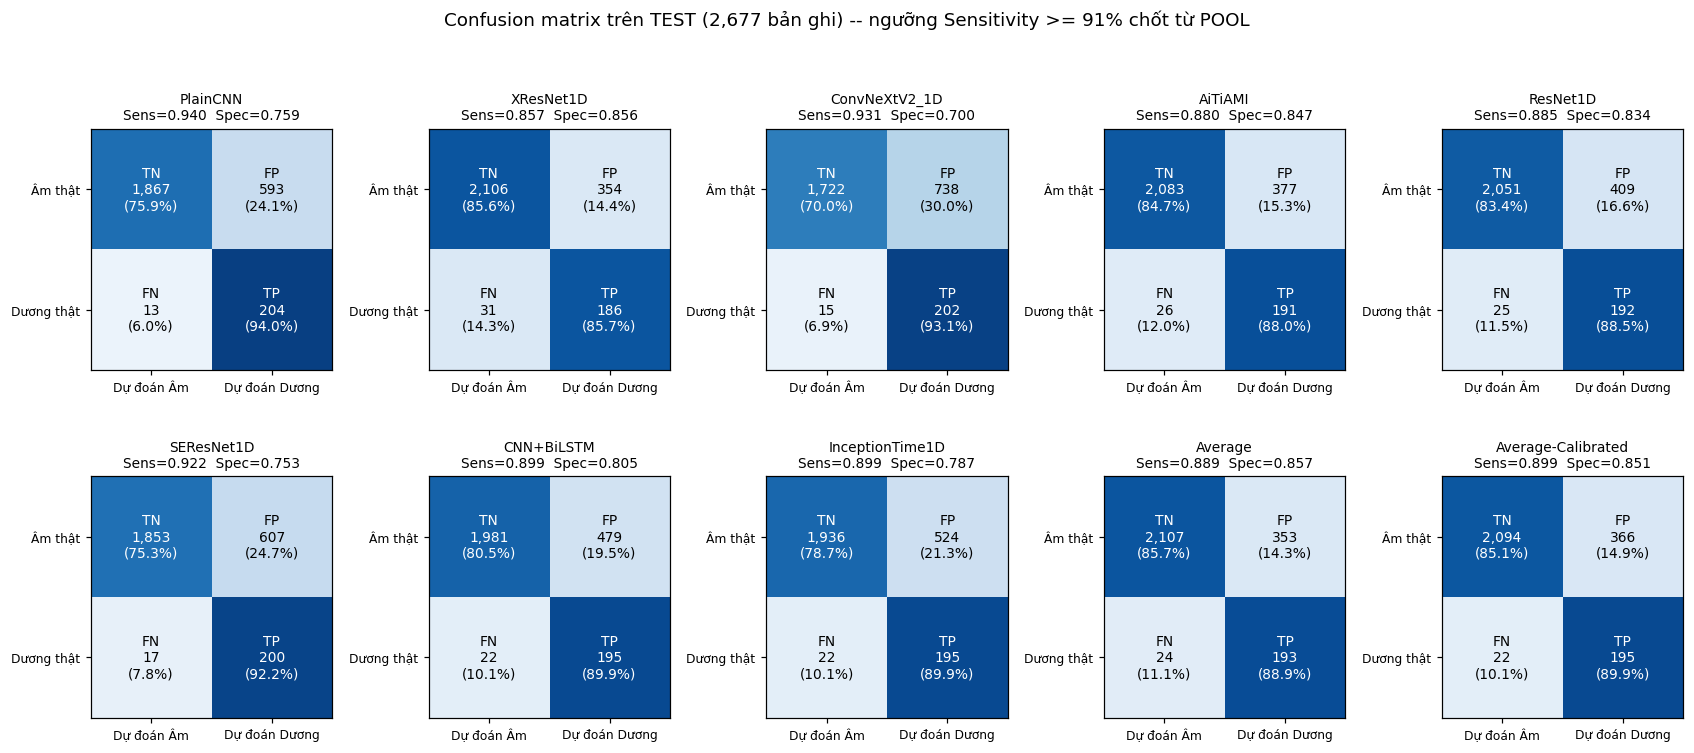

In [ ]:
def plot_confusion(ax, m, title):
    cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]], dtype=float)
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum > 0)
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            color = "white" if cm_pct[i, j] > 0.55 else "black"
            ax.text(j, i, f"{labels[i][j]}\n{int(cm[i, j]):,}\n({cm_pct[i, j]:.1%})",
                   ha="center", va="center", fontsize=9, color=color)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Dự đoán Âm", "Dự đoán Dương"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Âm thật", "Dương thật"], fontsize=8)
    ax.set_title(f"{title}\nSens={m['sensitivity']:.3f}  Spec={m['specificity']:.3f}", fontsize=9)


_names_for_cm = CANDIDATES + ENSEMBLE_NAMES
_ncols = 5
_nrows = int(np.ceil(len(_names_for_cm) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.1 * _ncols, 3.4 * _nrows))
axes = np.atleast_2d(axes)
for i, name in enumerate(_names_for_cm):
    ax = axes[i // _ncols, i % _ncols]
    m = compute_metrics(y_test, TEST_P[name], FINAL_THRESHOLDS[name])
    plot_confusion(ax, m, name)
for i in range(len(_names_for_cm), _nrows * _ncols):
    axes[i // _ncols, i % _ncols].axis("off")
fig.suptitle(f"Confusion matrix trên TEST ({len(TEST_IDX):,} bản ghi) -- "
            f"ngưỡng Sensitivity >= {TARGET_SENSITIVITY:.0%} chốt từ POOL", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 21. Lưu bảng kết quả

In [ ]:
RESULTS_DIR = PERSIST_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_csv = RESULTS_DIR / f"stemi_test_metrics_{EXPERIMENT_TAG}.csv"
FINAL_TEST_DF.to_csv(out_csv, encoding="utf-8-sig")
print("Đã lưu bảng kết quả TEST ->", out_csv)
display(FINAL_TEST_DF)

# --- Lưu thêm 2 báo cáo mới (v2) để tham chiếu khi viết report ---
if len(QC_FLATLINE_REPORT):
    qc_csv = RESULTS_DIR / f"qc_flatline_{EXPERIMENT_TAG}.csv"
    QC_FLATLINE_REPORT.to_csv(qc_csv, index=False, encoding="utf-8-sig")
    print("Đã lưu báo cáo QC flatline ->", qc_csv)

focal_csv = RESULTS_DIR / f"focal_weight_diagnostic_{EXPERIMENT_TAG}.csv"
focal_diag_df.to_csv(focal_csv, encoding="utf-8-sig")
print("Đã lưu chẩn đoán trọng số Focal Loss ->", focal_csv)

Đã lưu bảng kết quả TEST -> /content/drive/MyDrive/ACS-ECG-AI/outputs/results/stemi_test_metrics_stemi_optimized_v2.csv


,Ngưỡng (từ POOL),AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV,F1,TP,FN,FP,TN
Model,,,,,,,,,,,,
Average,0.426157,0.946413,0.720780,0.889401,0.856504,0.353480,0.988738,0.505898,193,24,353,2107
Average-Calibrated,0.083974,0.946722,0.720707,0.898618,0.851220,0.347594,0.989603,0.501285,195,22,366,2094
ResNet1D,0.419410,0.933751,0.692879,0.884793,0.833740,0.319468,0.987958,0.469438,192,25,409,2051
AiTiAMI,0.431884,0.940015,0.688530,0.880184,0.846748,0.336268,0.987672,0.486624,191,26,377,2083
XResNet1D,0.419351,0.931482,0.687399,0.857143,0.856098,0.344444,0.985494,0.491413,186,31,354,2106
CNN+BiLSTM,0.334807,0.929829,0.686519,0.898618,0.805285,0.289318,0.989016,0.437710,195,22,479,1981
InceptionTime1D,0.391755,0.935358,0.685631,0.898618,0.786992,0.271210,0.988764,0.416667,195,22,524,1936
SEResNet1D,0.408100,0.929335,0.672241,0.921659,0.753252,0.247831,0.990909,0.390625,200,17,607,1853
PlainCNN,0.378804,0.938908,0.668654,0.940092,0.758943,0.255960,0.993085,0.402367,204,13,593,1867


Đã lưu báo cáo QC flatline -> /content/drive/MyDrive/ACS-ECG-AI/outputs/results/qc_flatline_stemi_optimized_v2.csv
Đã lưu chẩn đoán trọng số Focal Loss -> /content/drive/MyDrive/ACS-ECG-AI/outputs/results/focal_weight_diagnostic_stemi_optimized_v2.csv
